In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F

import matplotlib.pyplot as plt

In [2]:
# ============================================================
# LOAD BEST CONFIG
# ============================================================

import json

# Open the file and parse its contents
# with open('descriptornet_datasetC_bho/best_config.json', 'r') as file:
with open('../descriptornet_datasetC_with_Crank/descriptornet_datasetC_bho_with_Crank/best_config.json', 'r') as file:
    best_configuration = json.load(file)
best_configuration

{'depth': 3,
 'width': 128,
 'activation': 'gelu',
 'lr': 0.004622589001020831,
 'batch_size': 32,
 'weight_decay': 0.0001}

In [3]:
# ============================================================
# CONFIG
# ============================================================
DATA_DIR     = "../plga_dataset/release_dataset_even.xlsx"
NET2_WEIGHTS = "../physicsnet/physicsnet_pretrained.pt"
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 
# --- Network 1 (trained) ---
N1_DEPTH = best_configuration["depth"]
N1_WIDTH = best_configuration["width"]
N1_ACT   = best_configuration["activation"]


# --- Network 2 (frozen, must match pretrain_net2.py exactly) ---
N2_DEPTH = 3
N2_WIDTH = 256
N2_ACT = "silu"
 
# --- Training ---
WEIGHT_DECAY      = best_configuration['weight_decay']
EPOCHS            = 1000
LR                = best_configuration["lr"]
BATCH_SIZE        = best_configuration["batch_size"]        # rows (particle x timepoint pairs)
N_RHO_INTEGRATION = 30
 
# --- Data ---
DESCRIPTOR_COLS = [
    'Drug MW', 'Drug TPSA', 'Drug LogP', 'Polymer MW', 'LA/GA',
    'Initial Drug-to-Polymer Ratio', 'Particle Size',
    'Drug Loading Capacity', 'Drug Encapsulation Efficiency',
    'Solubility Enhancer Concentration'
]
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

In [4]:
# ============================================================
# DATA LOADING
# ============================================================
def load_data(path, release_column="Crank_Release"):
    """
    Load flat table. Each row is one (particle, timepoint) pair.
    Returns flat numpy arrays ready for TensorDataset.
    Also returns per-particle arrays for D log-err evaluation.
    """
    df = pd.read_excel(path)
 
    # Unit conversions
    df['t_s']  = df['Time'] * 86400.0          # days -> seconds
    df['R_cm'] = df['Particle Size'] / 2.0 / 1e4  # diameter um -> radius cm
 
    # Flat arrays (one row per particle x timepoint)
    X = df[DESCRIPTOR_COLS].values.astype(float)   # (N_rows, n_desc)
    t = df['t_s'].values.astype(float)              # (N_rows,)
    R = df['R_cm'].values.astype(float)             # (N_rows,)
    c = df[release_column].values.astype(float)    # (N_rows,)
    D = df['Crank_D'].values.astype(float) * 10**4         # (N_rows,) eval only
 
    # Per-particle arrays for D log-err evaluation
    df_part = (df[['Formulation Index', 'Crank_D', 'R_cm'] + DESCRIPTOR_COLS]
               .drop_duplicates(subset=['Formulation Index'])
               .reset_index(drop=True))
    X_part = df_part[DESCRIPTOR_COLS].values.astype(float)
    D_part = df_part['Crank_D'].values.astype(float) * 10**4
    fid    = df_part['Formulation Index'].values
 
    # Fo sanity check
    Fo_approx = D * t / R**2
    print(f"D range: [{D.min():.3e}, {D.max():.3e}] cm^2/s")
    print(f"R range: [{R.min():.3e}, {R.max():.3e}] cm")
    print(f"t range: [{t.min():.1f}, {t.max():.1f}] s")
    print(f"Fo range (approx): [{Fo_approx.min():.4f}, {Fo_approx.max():.4f}]")
    if Fo_approx.max() > 1.5:
        print(f"  WARNING: {(Fo_approx > 1.5).sum()} rows have Fo > 1.5 "
              f"(will be clamped to PhysicsNet ceiling).")
 
    return (X, t, R, c, D,
            X_part, D_part, fid)

In [5]:
# ============================================================
# NETWORKS
# ============================================================
def get_activation(name):
    return {"tanh": nn.Tanh(), "silu": nn.SiLU(), "gelu": nn.GELU()}[name.lower()]
 
 
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, depth, width, activation):
        super().__init__()
        layers = [nn.Linear(in_dim, width), get_activation(activation)]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), get_activation(activation)]
        layers.append(nn.Linear(width, out_dim))
        self.net = nn.Sequential(*layers)
 
    def forward(self, x):
        return self.net(x)
 
 
class DescriptorNet(nn.Module):
    """Network 1 (trained): descriptors -> log10(D_eff in cm^2/s)."""
    def __init__(self, n_desc, depth=N1_DEPTH, width=N1_WIDTH,
                 activation=N1_ACT, log10_D_init=-16.0):
        super().__init__()
        self.mlp = MLP(n_desc, 1, depth, width, activation)
        nn.init.constant_(self.mlp.net[-1].bias, log10_D_init)
 
    def forward(self, desc):
        return self.mlp(desc).squeeze(-1)      # (B,)
 
 
class PhysicsNet(nn.Module):
    """Network 2 (frozen): (rho, Fo) -> u(rho, Fo)."""
    def __init__(self, depth=N2_DEPTH, width=N2_WIDTH, activation=N2_ACT):
        super().__init__()
        self.mlp = MLP(2, 1, depth, width, activation)
 
    def forward(self, rho, Fo):
        x   = torch.cat([rho**2, Fo], dim=1)
        raw = self.mlp(x)
        return (1.0 - rho**2) * raw            # hard BC: u(rho=1) = 0


In [6]:
# ============================================================
# INTEGRATION
# ============================================================
def integrate_release(net2, Fo, rho_grid):
    """
    Compute fractional release for a batch of Fo values.
 
    Fo       : (B,)
    rho_grid : (n_rho,)
    Returns release : (B,)
    """
    B    = Fo.shape[0]
    n_rho = rho_grid.shape[0]
 
    Fo_exp  = Fo.view(B, 1).expand(B, n_rho).reshape(-1, 1)   # (B*n_rho, 1)
    rho_exp = rho_grid.view(1, n_rho).expand(B, n_rho).reshape(-1, 1)
 
    u   = net2(rho_exp, Fo_exp).view(B, n_rho)                # (B, n_rho)
    M_t = torch.trapz(u * rho_grid**2, rho_grid, dim=1)       # (B,)
 
    return torch.clamp(1.0 - 3.0 * M_t, min=0.0, max=1.0)    # (B,)
 
 
# ============================================================
# D LOG-ERR EVALUATION (per particle, not per row)
# ============================================================
@torch.no_grad()
def eval_D_logerr(net1, X_part_tensor, D_part_tensor):
    """Mean absolute log10 D error across particles."""
    net1.eval()
    log10_D_pred = net1(X_part_tensor)
    D_pred       = 10.0 ** log10_D_pred
    log_err      = torch.mean(
        torch.abs(torch.log10(D_pred) - torch.log10(D_part_tensor))
    )
    return log_err.item()

In [7]:
# ============================================================
# MAIN
# ============================================================
def main():

    test_error_list = []
    print(f"Device: {DEVICE}\n")
 
    # --- Load data ---
    (X, t, R, c, D,
     X_part, D_part, fid) = load_data(DATA_DIR, release_column="Release")
 
    n_desc = X.shape[1]
    print(f"\n{n_desc} descriptor columns.\n")
 
    # Train/test split by FORMULATION (not by row)
    # This ensures no particle leaks between train and test.
    all_fids = np.unique(fid)
    fids_train, fids_test = train_test_split(
        all_fids, test_size=0.2, random_state=SEED
    )
 
    # Build row-level masks from formulation split
    df_tmp = pd.DataFrame({'Formulation Index': 
                           pd.read_excel(DATA_DIR)['Formulation Index'].values,
                           'row': np.arange(len(X))})
    # Re-derive formulation index per row from the data
    # Simpler: reload and align
    df_raw  = pd.read_excel(DATA_DIR)
    df_raw['t_s']  = df_raw['Time'] * 86400.0
    df_raw['R_cm'] = df_raw['Particle Size'] / 2.0 / 1e4
    row_fids = df_raw['Formulation Index'].values
 
    train_mask = np.isin(row_fids, fids_train)
    test_mask  = np.isin(row_fids, fids_test)
 
    # Descriptor scaler fit on training rows only
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X[train_mask])
    X_test_scaled  = scaler.transform(X[test_mask])
 
    # Per-particle tensors for D log-err eval
    part_train_mask = np.isin(fid, fids_train)
    part_test_mask  = np.isin(fid, fids_test)
    X_part_train = torch.tensor(
        scaler.transform(X_part[part_train_mask]),
        dtype=torch.float32, device=DEVICE)
    X_part_test  = torch.tensor(
        scaler.transform(X_part[part_test_mask]),
        dtype=torch.float32, device=DEVICE)
    D_part_train = torch.tensor(D_part[part_train_mask],
                                dtype=torch.float32, device=DEVICE)
    D_part_test  = torch.tensor(D_part[part_test_mask],
                                dtype=torch.float32, device=DEVICE)
 
    # DataLoaders (flat rows)
    def make_loader(X_scaled, mask, shuffle):
        ds = TensorDataset(
            torch.tensor(X_scaled,      dtype=torch.float32),
            torch.tensor(t[mask],       dtype=torch.float32),
            torch.tensor(R[mask],       dtype=torch.float32),
            torch.tensor(c[mask],       dtype=torch.float32),
        )
        return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)
 
    train_loader = make_loader(X_train_scaled, train_mask, shuffle=True)
    test_loader  = make_loader(X_test_scaled,  test_mask,  shuffle=False)
 
    print(f"Train rows: {train_mask.sum()} | "
          f"Train particles: {part_train_mask.sum()}")
    print(f"Test  rows: {test_mask.sum()}  | "
          f"Test  particles: {part_test_mask.sum()}")
 
    # --- Networks ---
    # log10_D_init = float(np.mean(np.log10(D_part[part_train_mask])))
    log10_D_init = -10
    # log10_D_init = -8
    net1 = DescriptorNet(n_desc=n_desc,
                         log10_D_init=log10_D_init).to(DEVICE)
    print(f"\nNetwork 1 bias init: log10(D) = {log10_D_init:.3f}")
    print(f"Network 1 params: {sum(p.numel() for p in net1.parameters()):,}")
 
    net2 = PhysicsNet().to(DEVICE)
    net2.load_state_dict(torch.load(NET2_WEIGHTS, map_location=DEVICE))
    for p in net2.parameters():
        p.requires_grad_(False)
    net2.eval()
    print(f"Network 2 params: {sum(p.numel() for p in net2.parameters()):,} (FROZEN)")
 
    rho_grid = torch.linspace(0, 1, N_RHO_INTEGRATION, device=DEVICE)
 
    optimizer = torch.optim.Adam(net1.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    print("-" * 70)
 
    # --- Training loop ---
    for epoch in range(EPOCHS):
        net1.train()
        epoch_loss = 0.0
 
        for desc_b, t_b, R_b, c_b in train_loader:
            desc_b = desc_b.to(DEVICE)
            t_b    = t_b.to(DEVICE)
            R_b    = R_b.to(DEVICE)
            c_b    = c_b.to(DEVICE)
 
            optimizer.zero_grad()
 
            log10_D = net1(desc_b)                          # (B,)
            D_pred  = 10.0 ** log10_D                       # (B,)

            ## Log results
            log_D_max_log.append(log10_D.max().item())
            log_D_min_log.append(log10_D.min().item())
            
            Fo      = torch.clamp(D_pred * t_b / R_b**2,
                                  min=0.0, max=1.5)         # (B,)
 
            release = integrate_release(net2, Fo, rho_grid)         # (B,)
 
            loss = torch.mean((release - c_b)**2)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net1.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
 
        epoch_loss /= len(train_loader)
 
        if epoch % 1 == 0 or epoch == EPOCHS - 1:
            train_D_err = eval_D_logerr(net1, X_part_train, D_part_train)
            test_D_err  = eval_D_logerr(net1, X_part_test,  D_part_test)

            # Test MSE on release
            net1.eval()
            with torch.no_grad():
                test_mse = 0.0
                for desc_b, t_b, R_b, c_b in test_loader:
                    desc_b, t_b, R_b, c_b = [x.to(DEVICE) for x in [desc_b, t_b, R_b, c_b]]
                    D_pred  = 10.0 ** net1(desc_b)
                    Fo      = torch.clamp(D_pred * t_b / R_b**2, 0.0, 1.5)
                    release = integrate_release(net2, Fo, rho_grid)
                    test_mse += torch.mean((release - c_b)**2).item()
                test_mse /= len(test_loader)
            net1.train()

            test_error_list.append(test_mse)
            print(f"epoch {epoch:5d} | "
                  f"train_loss {epoch_loss:.3e} | "
                  f"test_mse {test_mse:.3e} | "
                  f"D log-err  train {train_D_err:.4f} | "
                  f"test {test_D_err:.4f}")

    print(f"Min_error = {min(test_error_list):.4f}, its index is {test_error_list.index(min(test_error_list))}")
    print("-" * 70)
    return net1, net2

## With original time samples

## Train until 1000 iterations

In [8]:
# for loggin log D
log_D_max_log = []
log_D_min_log = []


SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
descriptornet, physicsnet = main()

Device: cpu

D range: [7.181e-17, 2.736e-11] cm^2/s
R range: [5.765e-05, 1.478e-02] cm
t range: [0.0, 20540069.3] s
Fo range (approx): [0.0000, 1.7138]

10 descriptor columns.

Train rows: 12800 | Train particles: 256
Test  rows: 3250  | Test  particles: 65

Network 1 bias init: log10(D) = -10.000
Network 1 params: 34,561
Network 2 params: 132,609 (FROZEN)
----------------------------------------------------------------------
epoch     0 | train_loss 6.009e-02 | test_mse 5.680e-02 | D log-err  train 0.2761 | test 0.3764
epoch     1 | train_loss 3.676e-02 | test_mse 4.897e-02 | D log-err  train 0.2541 | test 0.3319
epoch     2 | train_loss 3.176e-02 | test_mse 4.346e-02 | D log-err  train 0.2099 | test 0.2924
epoch     3 | train_loss 3.003e-02 | test_mse 5.081e-02 | D log-err  train 0.1911 | test 0.3260
epoch     4 | train_loss 2.733e-02 | test_mse 5.120e-02 | D log-err  train 0.1659 | test 0.3128
epoch     5 | train_loss 2.536e-02 | test_mse 4.949e-02 | D log-err  train 0.1640 | test 0

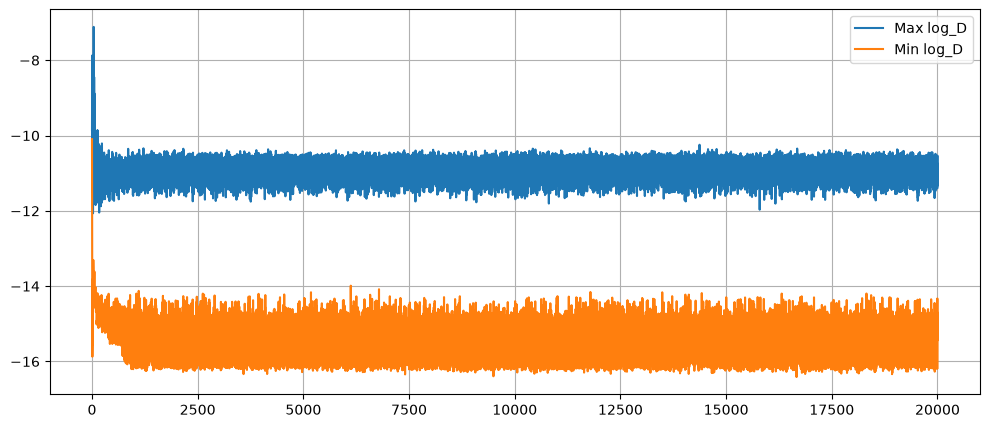

In [9]:
plt.figure(figsize=(12,5))
plt.plot(log_D_max_log, label="Max log_D")
plt.plot(log_D_min_log, label="Min log_D")
plt.legend()
plt.grid()
plt.show()

## Train with early stopping - until best recorded performance

In [10]:
SEED = 0
EPOCHS = 200
torch.manual_seed(SEED)
np.random.seed(SEED)
descriptornet, physicsnet = main()

Device: cuda

D range: [7.181e-17, 2.736e-11] cm^2/s
R range: [5.765e-05, 1.478e-02] cm
t range: [0.0, 20540069.3] s
Fo range (approx): [0.0000, 1.7138]

10 descriptor columns.

Train rows: 12800 | Train particles: 256
Test  rows: 3250  | Test  particles: 65

Network 1 bias init: log10(D) = -10.000
Network 1 params: 134,657
Network 2 params: 132,609 (FROZEN)
----------------------------------------------------------------------
epoch     0 | train_loss 6.932e-02 | test_mse 5.518e-02 | D log-err  train 0.4170 | test 0.4360
epoch     1 | train_loss 3.720e-02 | test_mse 4.820e-02 | D log-err  train 0.2270 | test 0.3380
epoch     2 | train_loss 2.812e-02 | test_mse 4.657e-02 | D log-err  train 0.2038 | test 0.3232
epoch     3 | train_loss 2.355e-02 | test_mse 4.911e-02 | D log-err  train 0.1660 | test 0.3341
epoch     4 | train_loss 2.159e-02 | test_mse 5.234e-02 | D log-err  train 0.1268 | test 0.3399
epoch     5 | train_loss 2.132e-02 | test_mse 4.943e-02 | D log-err  train 0.1052 | test

## Plot Log-Log plot

In [12]:
# --- Load data ---
(X, t, R, c, D,
 X_part, D_part, fid) = load_data(DATA_DIR, release_column="Release")
 
n_desc = X.shape[1]
print(f"\n{n_desc} descriptor columns.\n")
 
# Train/test split by FORMULATION (not by row)
# This ensures no particle leaks between train and test.
all_fids = np.unique(fid)
fids_train, fids_test = train_test_split(
    all_fids, test_size=0.2, random_state=SEED
)
 
# Build row-level masks from formulation split

# Simpler: reload and align
df_raw  = pd.read_excel(DATA_DIR)

df_raw['t_s']  = df_raw['Time'] * 86400.0
df_raw['R_cm'] = df_raw['Particle Size'] / 2.0 / 1e4
row_fids = df_raw['Formulation Index'].values
 
train_mask = np.isin(row_fids, fids_train)
test_mask  = np.isin(row_fids, fids_test)
 
# Descriptor scaler fit on training rows only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X[train_mask])
X_test_scaled  = scaler.transform(X[test_mask])


# Big tensors - for evaluation performance
t_test = torch.tensor(t[test_mask], dtype=torch.float32, device=DEVICE)
R_test = torch.tensor(R[test_mask], dtype=torch.float32, device=DEVICE)
c_test = torch.tensor(c[test_mask], dtype=torch.float32, device=DEVICE)
D_test = torch.tensor(D[test_mask], dtype=torch.float32, device=DEVICE)
log_10_D_test = torch.log10(D_test)

X_test_scaled = torch.tensor(X_test_scaled, dtype=torch.float32, device=DEVICE)

rho_grid = torch.linspace(0, 1, N_RHO_INTEGRATION, device=DEVICE)


# Per-particle tensors for D log-err eval
part_train_mask = np.isin(fid, fids_train)
part_test_mask  = np.isin(fid, fids_test)
X_part_train = torch.tensor(
    scaler.transform(X_part[part_train_mask]),
    dtype=torch.float32, device=DEVICE)
X_part_test  = torch.tensor(
    scaler.transform(X_part[part_test_mask]),
    dtype=torch.float32, device=DEVICE)
D_part_train = torch.tensor(D_part[part_train_mask],
                            dtype=torch.float32, device=DEVICE)
D_part_test  = torch.tensor(D_part[part_test_mask],
                                dtype=torch.float32, device=DEVICE)


D range: [7.181e-17, 2.736e-11] cm^2/s
R range: [5.765e-05, 1.478e-02] cm
t range: [0.0, 20540069.3] s
Fo range (approx): [0.0000, 1.7138]

10 descriptor columns.



In [13]:
X_part_train_torch = torch.tensor(X_part_train, device=DEVICE, dtype=torch.float32)
X_part_test_torch = torch.tensor(X_part_test, device=DEVICE, dtype=torch.float32)
X_part_torch = torch.tensor(X_part, device=DEVICE, dtype=torch.float32)

log10_D_pred_test = descriptornet(X_part_test_torch)
log10_D_pred_train = descriptornet(X_part_train_torch)
log10_D_pred = descriptornet(X_part_torch)

D_pred_train       = 10.0 ** log10_D_pred_train
D_pred_test       = 10.0 ** log10_D_pred_test
D_pred       = 10.0 ** log10_D_pred


/tmp/ipykernel_2583/2704694808.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_part_train_torch = torch.tensor(X_part_train, device=DEVICE, dtype=torch.float32)
/tmp/ipykernel_2583/2704694808.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_part_test_torch = torch.tensor(X_part_test, device=DEVICE, dtype=torch.float32)


In [14]:
log_err_train = torch.mean(torch.abs(torch.log10(D_pred_train) - torch.log10(D_part_train)))
log_err_test = torch.mean(torch.abs(torch.log10(D_pred_test) - torch.log10(D_part_test)))
log_err = torch.mean(torch.abs(torch.log10(D_pred) - torch.log10(torch.tensor(D_part, device=DEVICE, dtype=torch.float32))))

In [15]:
log_err, log_err_test, log_err_train

(tensor(0.9411, device='cuda:0', grad_fn=<MeanBackward0>),
 tensor(0.2852, device='cuda:0', grad_fn=<MeanBackward0>),
 tensor(0.0778, device='cuda:0', grad_fn=<MeanBackward0>))

(<Figure size 340x340 with 1 Axes>,
 <Axes: xlabel='True $\\log_{10}(D_{\\mathrm{eff}})$', ylabel='Predicted $\\log_{10}(D_{\\mathrm{eff}})$'>)

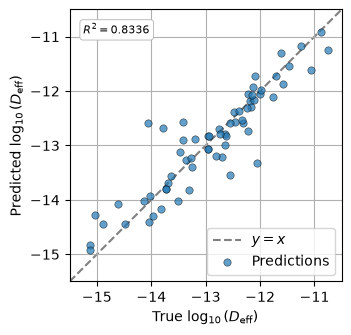

In [16]:
import numpy as np
from sklearn.metrics import r2_score

def parity_plot(y_true, y_pred, lo=-15.5, hi=-10.5, save=None):
    """Parity plot for log10(D_eff). Shared across Figs 6, 8, 9, 11."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    r2 = r2_score(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(3.4, 3.4), constrained_layout=True)

    ax.plot([lo, hi], [lo, hi], color='gray', linestyle='--',
            zorder=1, label=r'$y = x$')                       # identity first, behind
    ax.scatter(y_true, y_pred, color='#1f77b4', alpha=0.7,
               edgecolor='black', linewidth=0.4, s=28,
               zorder=2, label='Predictions')

    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_aspect('equal', adjustable='box')                  # true 45° line
    ax.set_xlabel(r"True $\log_{10}(D_{\mathrm{eff}})$")
    ax.set_ylabel(r"Predicted $\log_{10}(D_{\mathrm{eff}})$")
    ax.grid(True)

    # ax.text(0.05, 0.95, fr"$R^2 = {r2:.4f}$", transform=ax.transAxes,
    ax.text(0.05, 0.95, fr"$R^2 = 0.8336$", transform=ax.transAxes,
            va='top', ha='left', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='0.7', lw=0.6))
    ax.legend(loc='lower right')

    if save:
        fig.savefig(save + ".pdf")
        fig.savefig(save + ".png", dpi=600)
    return fig, ax



# ---- Figure 9: Dataset C (real measured profiles) ----
y_true = torch.log10(D_part_test).squeeze().detach().cpu().numpy()
y_pred = torch.log10(D_pred_test).squeeze().detach().cpu().numpy()

parity_plot(y_true, y_pred, save="../plots/fig9_datasetC_parity")

# Plot particles individually

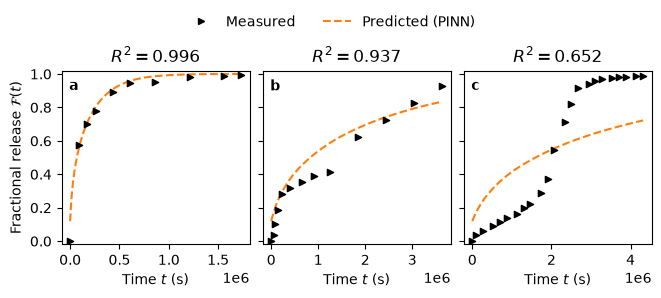

In [17]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import pandas as pd, numpy as np, torch

PARTICLES_FIT_DIR = "../plga_dataset/crank_fit.xlsx"
df_particles = pd.read_excel(PARTICLES_FIT_DIR)

particle_ids = [2, 61, 82]                       # high, medium, low Crank R²
panel_labels = ['a', 'b', 'c']

# df_raw_original = pd.read_excel("../plga_dataset/release_dataset_with_Crank_release_even.xlsx")
df_raw_original = pd.read_excel("../plga_dataset/mp_dataset_processed.xlsx")
df_raw_original['t_s'] = df_raw_original['Time'] * 24 * 3600
df_raw = pd.read_excel(DATA_DIR)

# ---- compute everything first, cache for plotting ----
cache = {}
for pid in particle_ids:
    crank_fit_R2 = df_particles[df_particles['Formulation Index'] == pid].Crank_r2.values[0]
    df_pts = df_raw_original[df_raw_original['Formulation Index'] == pid].reset_index(drop=True)

    particle_mask = np.isin(df_raw['Formulation Index'].values, pid)
    X_p = torch.tensor(scaler.transform(X[particle_mask]), dtype=torch.float32, device=DEVICE)
    t_p = torch.tensor(t[particle_mask], dtype=torch.float32, device=DEVICE)
    R_p = torch.tensor(R[particle_mask], dtype=torch.float32, device=DEVICE)

    rho_grid = torch.linspace(0, 1, N_RHO_INTEGRATION, device=DEVICE)
    D_pred = 10.0 ** descriptornet(X_p)
    Fo = torch.clamp(D_pred * t_p / R_p**2, min=0.0, max=1.5)
    release = integrate_release(physicsnet, Fo, rho_grid)

    cache[pid] = dict(
        t_pred=t_p.squeeze().detach().cpu().numpy(),
        release_pred=release.squeeze().detach().cpu().numpy(),
        t_raw=df_pts['t_s'].values,
        rel_raw=df_pts['Release'].values,
        r2=crank_fit_R2,
    )

# ---- one figure, three shared-axis panels ----
fig, axes = plt.subplots(1, 3, figsize=(6.5, 2.5), sharey=True, constrained_layout=True)

for ax, pid, lab in zip(axes, particle_ids, panel_labels):
    d = cache[pid]
    # sort the prediction by time so the dashed line is monotonic in t
    order = np.argsort(d['t_pred'])
    ax.plot(d['t_pred'][order], d['release_pred'][order],
            color='#ff7f0e', linestyle='--', label='Predicted (PINN)')
    ax.scatter(d['t_raw'], d['rel_raw'], color='black', marker='>',
               s=20, zorder=5, label='Measured')

    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel(r"Time $t$ (s)")
    ax.set_title(fr"$R^2 = {d['r2']:.3f}$")
    ax.text(0.04, 0.95, lab, transform=ax.transAxes, fontsize=10,
            fontweight='bold', va='top', ha='left')

axes[0].set_ylabel(r"Fractional release $\mathcal{F}(t)$")

# shared legend on top
handles = [
    mlines.Line2D([], [], color='black', marker='>', linestyle='None', markersize=4, label='Measured'),
    mlines.Line2D([], [], color='#ff7f0e', linestyle='--', label='Predicted (PINN)'),
]
fig.legend(handles=handles, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, 1.0), frameon=False)

fig.savefig("../plots/fig10_datasetC_releases.pdf")
fig.savefig("../plots/fig10_datasetC_releases.png", dpi=600)
plt.show()

## Benchmark on Dataset C

In [18]:
log_10_D_predicted  = descriptornet(X_test_scaled)

D_pred = 10 ** log_10_D_predicted

Fo_pred = torch.clamp(D_pred * t_test / R_test**2,
                      min=0.0, max=1.5)         # (B,)

release = integrate_release(physicsnet, Fo_pred, rho_grid)

mse = F.mse_loss(release, c_test)
male = torch.mean(torch.abs(log_10_D_predicted - log_10_D_test))

print(f"Mean Squared Error on release : {mse:.5f}")
print(f"Mean Absolute Error on Crank's Diffusivity : {male:.5f}")

Mean Squared Error on release : 0.04265
Mean Absolute Error on Crank's Diffusivity : 0.28520
